In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# === Data Preprocessing ===

In [2]:
# Install BUET Bengali Normalizer
!pip install -q git+https://github.com/csebuetnlp/normalizer

import pandas as pd
import numpy as np
import re
import json
from bs4 import BeautifulSoup
import emoji
import matplotlib.pyplot as plt
import seaborn as sns


# Text Normalization
from normalizer import normalize

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
dataset_path = "/content/drive/MyDrive/our-thesis-dataset-4.xlsx"
df = pd.read_excel(dataset_path)
df.head(10)

,Sentence,Sentiment
0,ওয়েল ডান,Positive
1,যুগোপযুগী সিদ্ধান্ত,Positive
2,যুগোপযোগী সংশোধন,Positive
3,যৌক্তিক প্রস্তাব,Positive
4,যৌক্তিকতা আছে।,Positive
5,সময়োপযোগী পদক্ষেপ,Positive
6,সুদূরপ্রসারী সিদ্ধান্ত।,Positive
7,সুন্দর পদক্ষেপে,Positive
8,💯পারসেন্ট সঠিক সিদ্ধান্ত,Positive
9,অতি প্রয়োজনীয় উদ্যোগ,Positive


In [4]:
# Function to remove unwanted elements
def clean_comment(text):

  if pd.isna(text):
        return ""

  # Apply BUET NORMALIZER
  text = normalize(text, unicode_norm="NFKC")

  # Remove HTML tags
  text = BeautifulSoup(text, "html.parser").get_text()

  # Remove URLs
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

  # Remove mentions & hashtags
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#\w+', '', text)

  # Remove English digits (0-9) and Bengali digits (০-৯)
  text = re.sub(r'\d+', '', text)

  # # Fix repeated characters (any char ×3 or more)
  text = re.sub(r'(.)\1{2,}', r'\1', text)

  # Remove duplicate diacritics
  text = re.compile(r'([ািীুূেৈোৌংঁঃ])\1+').sub(r'\1', text)

  # Remove Zero-width characters
  text = text.replace("\u200c", "").replace("\u200d", "")

  # Remove all emojis
  emoji_pattern = re.compile(
      "["
      u"\U0001F600-\U0001F64F"  # emoticons
      u"\U0001F300-\U0001F5FF"  # symbols & pictographs
      u"\U0001F680-\U0001F6FF"  # transport & map symbols
      u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
      u"\U00002702-\U000027B0"  # Dingbats
      u"\U000024C2-\U0001F251"  # Enclosed characters
      u"\U0001F900-\U0001F9FF"  # Supplemental symbols and pictographs
      u"\U0001FA70-\U0001FAFF"  # Symbols and pictographs extended-A
      u"\U0001F018-\U0001F270"  # Various Asian characters
      u"\U0001F300-\U0001F5FF"  # Miscellaneous symbols and pictographs
      "]+", flags=re.UNICODE)
  text = emoji_pattern.sub(r'', text)
  text = emoji.replace_emoji(text, replace='')

  # Remove all non-Bengali characters (Everything not Bengali letter, space, or halant)
  text = re.sub(r'[^\u0980-\u09FF\s্]', ' ', text)

  # Replace spaces/tabs/newlines/leading or tailing spaces with single space
  text = re.sub(r'\s+', ' ', text).strip()

  # remove single Bengali character 'অ', 'ঃ', '।'
  text = ' '.join(w for w in text.split() if len(w) >= 2)

  return text

# Clean text
df["Clean Sentence"] = df["Sentence"].apply(clean_comment)
print("Cleaning text data...")

Cleaning text data...


In [5]:
df.head(10)

,Sentence,Sentiment,Clean Sentence
0,ওয়েল ডান,Positive,ওয়েল ডান
1,যুগোপযুগী সিদ্ধান্ত,Positive,যুগোপযুগী সিদ্ধান্ত
2,যুগোপযোগী সংশোধন,Positive,যুগোপযোগী সংশোধন
3,যৌক্তিক প্রস্তাব,Positive,যৌক্তিক প্রস্তাব
4,যৌক্তিকতা আছে।,Positive,যৌক্তিকতা আছে
5,সময়োপযোগী পদক্ষেপ,Positive,সময়োপযোগী পদক্ষেপ
6,সুদূরপ্রসারী সিদ্ধান্ত।,Positive,সুদূরপ্রসারী সিদ্ধান্ত
7,সুন্দর পদক্ষেপে,Positive,সুন্দর পদক্ষেপে
8,💯পারসেন্ট সঠিক সিদ্ধান্ত,Positive,পারসেন্ট সঠিক সিদ্ধান্ত
9,অতি প্রয়োজনীয় উদ্যোগ,Positive,অতি প্রয়োজনীয় উদ্যোগ


In [6]:
print("Counting duplicates...")

# Total duplicates
total_duplicates = df['Clean Sentence'].duplicated().sum()
print(f"\nTotal duplicate sentences: {total_duplicates}")

# Duplicates per class
duplicates_per_class = df.groupby('Sentiment')['Clean Sentence'].apply(lambda x: x.duplicated().sum())
print("\nDuplicate sentences per sentiment class:")
print(duplicates_per_class)

Counting duplicates...

Total duplicate sentences: 38

Duplicate sentences per sentiment class:
Sentiment
Negative     7
Neutral      7
Positive    18
Name: Clean Sentence, dtype: int64


# === Exploratory data analysis (EDA) ===

In [ ]:
print("Total Dataset Size (After Cleaning):", df.shape[0])
print(df["Sentiment"].value_counts())

Total Dataset Size (After Cleaning): 6000
Sentiment
Positive    2000
Neutral     2000
Negative    2000
Name: count, dtype: int64


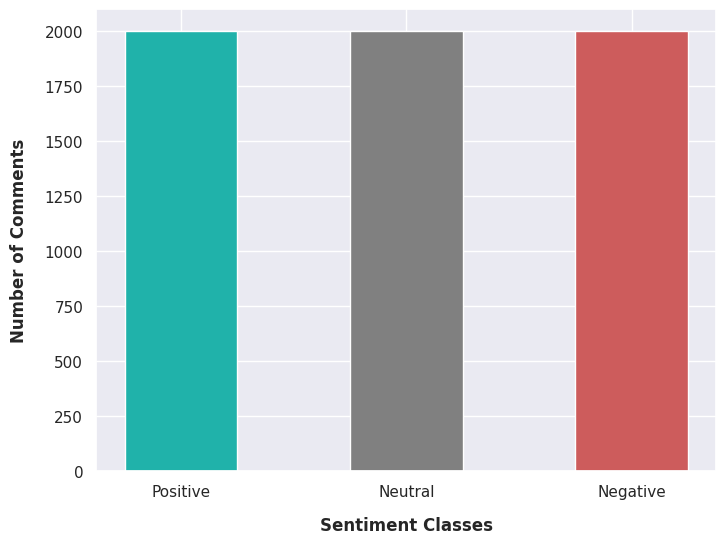

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1)

# Sentiment count
sentiment_counts = df["Sentiment"].value_counts()

# নির্দিষ্ট order রাখতে চাইলে
sentiment_counts = sentiment_counts[["Positive", "Neutral", "Negative"]]

# আলাদা color
colors = ["lightseagreen", "gray", "indianred"]

plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, width=0.5)

plt.xlabel("Sentiment Classes", labelpad=12, fontweight='bold')
plt.ylabel("Number of Comments", labelpad=12, fontweight='bold')

# plt.title("Class Distribution of the Dataset", fontweight='bold', pad=15)

plt.savefig("class_distribution_vertical.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import numpy as np

def data_summary(dataset):
    """
    Modified to match your dataset columns: 'Sentiment' and 'Clean Sentence'
    """
    documents = []
    words = []
    u_words = []

    # Using 'Clean Sentence' based on your screenshot
    # We use .astype(str) to ensure no errors if there are empty/NaN rows
    total_u_words = [word.strip() for t in dataset['Clean Sentence'].astype(str) for word in t.strip().split()]

    # Using 'Sentiment' based on your screenshot
    class_label = [k for k, v in dataset['Sentiment'].value_counts().to_dict().items()]

    for label in class_label:
        # Filter rows for the specific class
        filtered_data = dataset[dataset['Sentiment'] == label]['Clean Sentence'].astype(str)

        # Create word list
        word_list = [word.strip() for t in filtered_data for word in t.strip().split()]

        counts = dict()
        for word in word_list:
            counts[word] = counts.get(word, 0) + 1

        # Sort by frequency
        # ordered = sorted(counts.items(), key=lambda item: item[1], reverse=True)

        # Calculate stats
        doc_count = len(filtered_data)
        word_count = len(word_list)
        unique_word_count = len(np.unique(word_list))

        documents.append(doc_count)
        words.append(word_count)
        u_words.append(unique_word_count)

        print(f"\nClass Name : {label}")
        print(f"Number of Comments: {doc_count}")
        print(f"Number of Words: {word_count}")
        print(f"Number of Unique Words: {unique_word_count}")
        # print("Most Frequent Words:\n")

        # for k, v in ordered[:5]:
        #     print(f"{k}\t{v}")

    print(f"\nTotal Number of Unique Words in Dataset: {len(np.unique(total_u_words))}")

    return documents, words, u_words, class_label

# Call the function (assuming your dataframe is named 'df')
documents, words, u_words, class_names = data_summary(df)


Class Name : Positive
Number of Comments: 2000
Number of Words: 21709
Number of Unique Words: 3329

Class Name : Neutral
Number of Comments: 2000
Number of Words: 22833
Number of Unique Words: 5306

Class Name : Negative
Number of Comments: 2000
Number of Words: 18964
Number of Unique Words: 4230

Total Number of Unique Words in Dataset: 9065


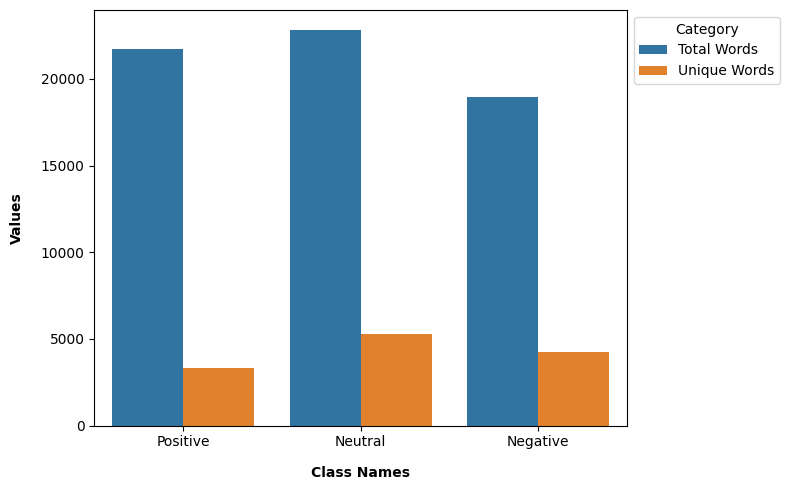

In [8]:
data_matrix = pd.DataFrame({
    'Total Words': words,
    'Unique Words': u_words,
    'Class Names': class_names
})

df_temp = pd.melt(data_matrix, id_vars="Class Names", var_name="Category", value_name="Values")

plt.figure(figsize=(8, 5))
ax = plt.subplot()

# বারপ্লট ড্র করা
sns_plot = sns.barplot(data=df_temp, x='Class Names', y='Values', hue='Category')

# --- প্রতিটা বারের উপরে অ্যামাউন্ট দেখানোর ম্যাজিক লাইন ---
# for container in ax.containers:
#     ax.bar_label(container, padding=1, fontsize=8)

# লিজেন্ড বাইরে সরানো
plt.legend(title='Category', bbox_to_anchor=(1, 1), loc='upper left')

plt.xlabel("Class Names", labelpad=12, fontweight='bold')
plt.ylabel("Values", labelpad=12, fontweight='bold')
# ax.set_title('Data Statistics')

# টিক লেবেল ফিক্স করা
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names)

plt.tight_layout()

# সেভ করা
plt.savefig("word_uniques_statistics.png", dpi=300, bbox_inches='tight')

plt.show()

In [9]:
# Length of each Reveiws
df['length'] = df['Clean Sentence'].apply(lambda x:len(x.split()))

df

,Sentence,Sentiment,Clean Sentence,length
0,ওয়েল ডান,Positive,ওয়েল ডান,2
1,যুগোপযুগী সিদ্ধান্ত,Positive,যুগোপযুগী সিদ্ধান্ত,2
2,যুগোপযোগী সংশোধন,Positive,যুগোপযোগী সংশোধন,2
3,যৌক্তিক প্রস্তাব,Positive,যৌক্তিক প্রস্তাব,2
4,যৌক্তিকতা আছে।,Positive,যৌক্তিকতা আছে,2
...,...,...,...,...
5995,ক্রেডিট চুরি করে বোষম্য জারি রাখাটা এখন তাদের ...,Negative,ক্রেডিট চুরি করে বোষম্য জারি রাখাটা এখন তাদের ...,35
5996,আগামী নির্বাচনে বিএনপিকে না বলুন বিএনপিকে গোল্...,Negative,আগামী নির্বাচনে বিএনপিকে না বলুন বিএনপিকে গোল্...,33
5997,জুলাই চার্টার যদি বিম্পির প্রপাগাণ্ডা পেপার হয়...,Negative,জুলাই চার্টার যদি বিম্পির প্রপাগাণ্ডা পেপার হয...,33
5998,জামাত চাচ্ছে ২৪ জুলাই দিয়ে মানুষ কে ৭১ এর গণহত...,Negative,জামাত চাচ্ছে জুলাই দিয়ে মানুষ কে এর গণহত্যার ...,27


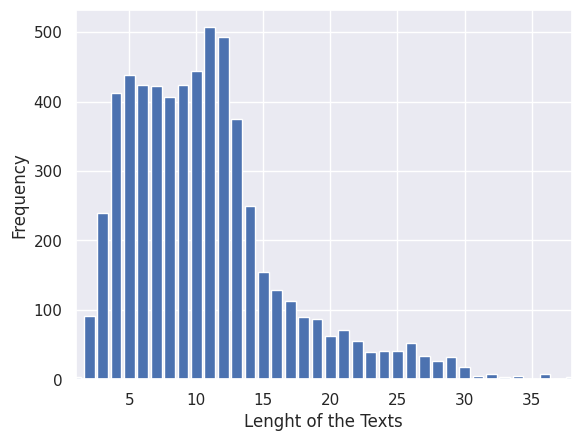

Maximum Length of a review: 38
Minimum Length of a review: 1
Average Length of a reviews: 11.0


In [ ]:
# Calculate the Review of each of the Review
frequency = {}
for i in df.length:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="b")
plt.xlim(1, max(df.length))
# in this notbook color is not working but it should work.
plt.xlabel('Lenght of the Texts')
plt.ylabel('Frequency')
# plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a review: {max(df.length)}")
print(f"Minimum Length of a review: {min(df.length)}")
print(f"Average Length of a reviews: {round(np.mean(df.length),0)}")

In [ ]:
print("Sentiment-wise Length Statistics:")
sentiment_length_stats = df.groupby('Sentiment')['length'].agg(['min', 'max', 'mean', 'median']).round(0)
print(sentiment_length_stats)

Sentiment-wise Length Statistics:
           min  max  mean  median
Sentiment                        
Negative     1   35   9.0     9.0
Neutral      2   38  11.0     9.0
Positive     2   38  11.0    10.0


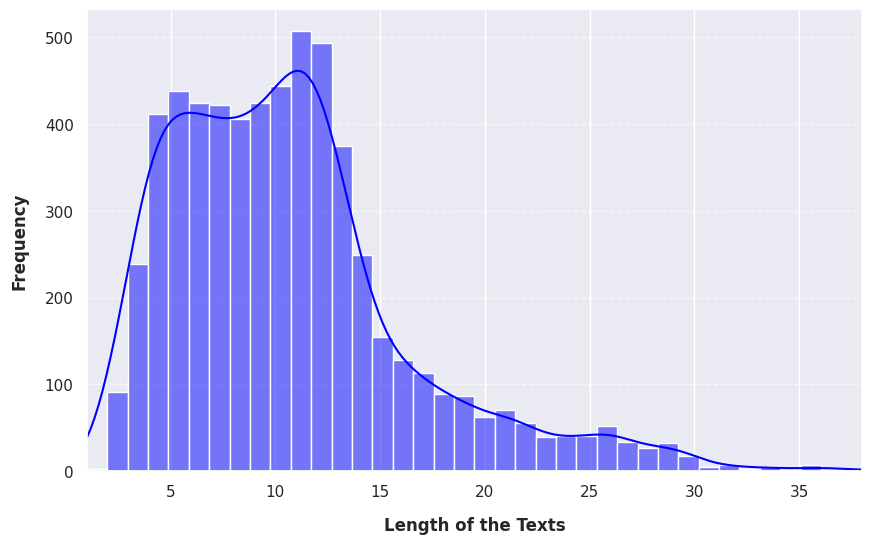

Maximum Length of a review: 38
Minimum Length of a review: 1
Average Length of a reviews: 11.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ১. ফিগার সাইজ সেট করা
plt.figure(figsize=(10, 6))

# ২. Seaborn histplot ব্যবহার করা
# kde=True দিলে হিস্টোগ্রামের ওপর দিয়ে একটি স্মুথ লাইন (ডিস্ট্রিবিউশন) দেখা যাবে
sns.histplot(df.length, bins=38, kde=True, color="blue")

# ৩. এক্সিস লিমিট এবং লেবেল সেট করা
plt.xlim(1, max(df.length))
plt.xlabel('Length of the Texts', labelpad=12, fontweight='bold')
plt.ylabel('Frequency', labelpad=12, fontweight='bold')
# plt.title('Distribution of Text Lengths', fontsize=14, fontweight='bold')

# ৪. গ্রিড অ্যাড করা (থিসিসের জন্য দেখতে ভালো লাগে)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ৫. প্লটটি সেভ করা (plt.show() এর আগে দিতে হবে)
plt.savefig("text_length_distribution.png", dpi=300, bbox_inches='tight')

# ৬. প্লট দেখানো
plt.show()

# স্ট্যাটিস্টিকস প্রিন্ট করা
print(f"Maximum Length of a review: {max(df.length)}")
print(f"Minimum Length of a review: {min(df.length)}")
print(f"Average Length of a reviews: {round(np.mean(df.length),0)}")

### Consolidated Text Length Counts (1-10 and >10)

In [ ]:
print("Overall text length counts for lengths 1-10:")
print(overall_length_counts)

# Overall count for lengths > 10
overall_10_plus_total = overall_length_counts_10_plus.sum()
print(f"\nOverall text length count for lengths > 10: {overall_10_plus_total}")

print("\nText length counts (1-10) per sentiment class:")
print(class_wise_length_counts)

# Class-wise count for lengths > 10
class_wise_10_plus_total = class_wise_length_counts_10_plus.sum(axis=1)
print("\nText length count (>10) per sentiment class:")
print(class_wise_10_plus_total)

Overall text length counts for lengths 1-10:
length
1       3
2      91
3     239
4     412
5     438
6     424
7     422
8     406
9     424
10    444
Name: count, dtype: int64

Overall text length count for lengths > 10: 2697

Text length counts (1-10) per sentiment class:
length     1   2    3    4    5    6    7    8    9    10
Sentiment                                                
Negative    3  78  107  171  150  149  128  106  119  120
Neutral     0   2   76  136  174  154  172  169  125  107
Positive    0  11   56  105  114  121  122  131  180  217

Text length count (>10) per sentiment class:
Sentiment
Negative    869
Neutral     885
Positive    943
dtype: int64


# === Data Split ===

In [12]:
X = df['Clean Sentence']
y = df['Sentiment']

# Prothome 80% Train ebong 20% baki ongsho (Temporary) vag kora
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Ebar oi 20% ke soman duivage vag kora (10% Validation ebong 10% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Now: X_train (80%), X_val (10%), X_test (10%)

print(30*"=")
print("Train Distribution (80%) (For Both ML & Transformer):")
print("Train shape:", X_train.shape)  # ≈80%
print(y_train.value_counts())

print(30*"=")
print("\nValidation Distribution (10%) (Only For Transformer):")
print("Val shape:", X_val.shape)      # ≈10%
print(y_val.value_counts())

print(30*"=")
print("\nTest Distribution (10%) (For Both ML & Transformer):")
print("Test shape:", X_test.shape)    # 10%
print(y_test.value_counts())

Train Distribution (80%) (For Both ML & Transformer):
Train shape: (4800,)
Sentiment
Positive    1600
Neutral     1600
Negative    1600
Name: count, dtype: int64

Validation Distribution (10%) (Only For Transformer):
Val shape: (600,)
Sentiment
Neutral     200
Negative    200
Positive    200
Name: count, dtype: int64

Test Distribution (10%) (For Both ML & Transformer):
Test shape: (600,)
Sentiment
Positive    200
Negative    200
Neutral     200
Name: count, dtype: int64


In [13]:
train_df_80 = pd.DataFrame({'text': X_train, 'sentiment': y_train})
val_df_10   = pd.DataFrame({'text': X_val,   'sentiment': y_val})
test_df_10  = pd.DataFrame({'text': X_test,  'sentiment': y_test})

train_df_80.to_excel('train-thesis-4-80.xlsx', index=False)
val_df_10.to_excel('val-thesis-4-10.xlsx', index=False)
test_df_10.to_excel('test-thesis-4-10.xlsx', index=False)

print("Data splits saved as train-thesis-4-80.xlsx, val-thesis-4-10.xlsx, test-thesis-4-10.xlsx")

Data splits saved as train-thesis-4-80.xlsx, val-thesis-4-10.xlsx, test-thesis-4-10.xlsx
